# Visualization and comparison of predictions obtained by various models

In [1]:
import sys
sys.path.append("../.")
import numpy as np
import pandas as pd
from package.plots.plots import plot_multiple_obs_vs_pred

In [ ]:
OUTPUT_FEATURES = ['deg_CmpBst_s_mapEff_in', 'deg_CmpBst_s_mapWc_in', 'deg_CmpFan_s_mapEff_in', 
                   'deg_CmpFan_s_mapWc_in', 'deg_CmpH_s_mapEff_in', 'deg_CmpH_s_mapWc_in', 
                   'deg_TrbH_s_mapEff_in', 'deg_TrbH_s_mapWc_in', 'deg_TrbL_s_mapEff_in', 
                   'deg_TrbL_s_mapWc_in']

In [4]:
observations = np.load("../data/predictions/observations.npy")
predictions_gb = np.load("../data/predictions/predictions_gb.npy")
predictions_mlp = np.load("../data/predictions/predictions_mlp.npy")
predictions_gru = np.load("../data/predictions/predictions_gru.npy")
predictions_kf = np.array(pd.read_csv("../data/predictions/predictions_kf.csv", header=None))
predictions_vjepa = np.array(pd.read_csv("../data/predictions/predictions_vjepa.csv", header=0))

In [5]:
tmp = np.full(observations.shape, np.nan)
tmp[-len(predictions_vjepa):] = predictions_vjepa
predictions_vjepa = tmp

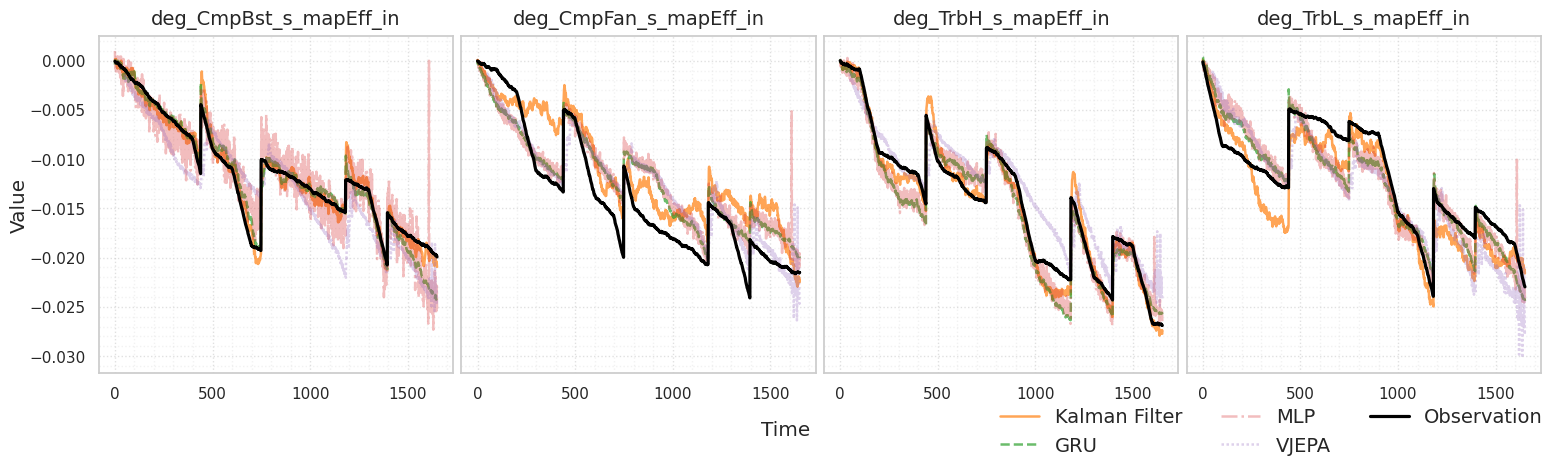

In [6]:
fig, axes = plot_multiple_obs_vs_pred(
    y_true=observations,
    y_pred=np.stack([predictions_kf, predictions_gru, predictions_mlp, predictions_vjepa], axis=0),                         # (3, T, 10)
    layout="1x4",
    model_names=["Kalman Filter", "GRU", "MLP", "VJEPA"],
    model_alpha=[0.7, 0.7,0.3, 0.3],
    variable_names=OUTPUT_FEATURES,
    variables=[0,2,6,8],
    palette="tab10",                           # or ["black", "C1", "C2", "C3"]
    legend_loc="bottom",
    legend_ncol=3,
    savepath=None
)